In [1]:
from FinMind.data import DataLoader
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
# plt.rcParams['font.sans-serif'] = ['Arial Unicode Ms']

api = DataLoader()

In [2]:
# 你要做資產配置的資產列表
portfolio = {
    '2414.TW': 0.25, # 中華電信
    '1314.TW': 0.25, # 中石化
    '1101.TW': 0.25, # 台泥
    '2330.TW': 0.25, # 台積電
}

In [3]:
all_datas = []
for key,value in portfolio.items():
    data = yf.download(key)
    all_datas.append(data)
all_data = pd.concat(all_datas,axis=1)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
returns = all_data['Adj Close'].pct_change()

In [10]:
# 用來儲存最佳化紀錄的容器
rs = []
# 取得有幾種資產
assets_n = returns.shape[1]
# 最佳化次數
optimal_n = 10000
# 初始資金
cap=500000
for portfolio in range(optimal_n):
    # 隨機產生N個亂數 並進行權重分配
    w = np.random.random(assets_n)
    w = w/sum(w)
    tmp_rs = list(w)

    # 加權後的 年化報酬率
    ann_ret=(returns+1).prod()  ** (252 / returns.count()) -1
    w_ann_ret = np.dot(w, ann_ret)  
    tmp_rs.append(w_ann_ret)
    
    # 加權後的資產標準差
    cov_matrix = returns.cov()
    var = cov_matrix.mul(w, axis=0).mul(w, axis=1).sum().sum() * 252
    ann_sd = var * 252
    tmp_rs.append(var)

    rs.append(tmp_rs)

In [ ]:
portfolios = pd.DataFrame(rs)
portfolios.columns = ['s1','s2','s3','s4','年化報酬','年化風險']


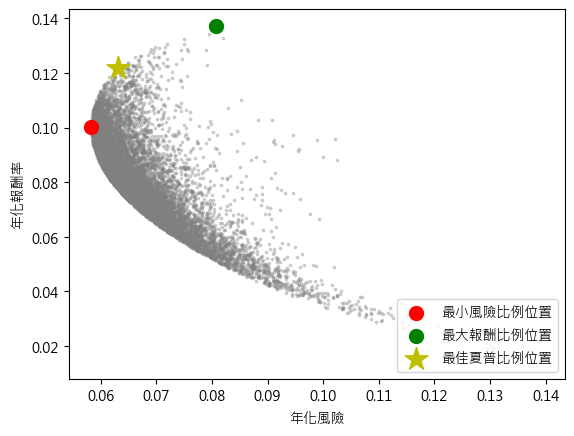

In [ ]:
# 進行效率前緣繪製
plt.scatter(portfolios['年化風險'], portfolios['年化報酬'], 
            color='grey', marker='o', s=3, alpha=0.3)

# 最小風險
min_risk = portfolios.loc[portfolios['年化風險']==portfolios['年化風險'].min()]
# 最大報酬
max_ret = portfolios.loc[portfolios['年化報酬']==portfolios['年化報酬'].max()]
# 最大夏普比例
rf = 0.01
portfolios['夏普值'] = (portfolios['年化報酬']) / portfolios['年化風險']
max_sharp = portfolios.loc[portfolios['夏普值']==portfolios['夏普值'].max()]

plt.scatter(min_risk['年化風險'], min_risk['年化報酬'], color='r', marker='o', s=100,label='最小風險比例位置')
plt.scatter(max_ret['年化風險'], max_ret['年化報酬'], color='g', marker='o', s=100,label='最大報酬比例位置')
plt.scatter(max_sharp['年化風險'], max_sharp['年化報酬'], color='y', marker='*', s=300,label='最佳夏普比例位置')
plt.xlabel('年化風險')
plt.ylabel('年化報酬率')
plt.legend( loc='lower right' )